In [1]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import pandas as pd
import os


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transform ready")

Transform ready


In [4]:
train_labels_path = "data/train/labels.csv"

df_train = pd.read_csv(train_labels_path)

print("Columns:", df_train.columns)
print(df_train.head())
print("Total rows:", len(df_train))

Columns: Index(['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle',
       'px_traffic_light', 'px_pedestrian', 'px_vehicle'],
      dtype='object')
   frame  has_traffic_light  has_pedestrian  has_vehicle  px_traffic_light  \
0      0              False           False         True                 0   
1     10              False            True         True                14   
2     20               True            True         True                99   
3     30               True            True         True                99   
4     40               True            True         True               101   

   px_pedestrian  px_vehicle  
0              0          85  
1            301        1138  
2            196         517  
3            181         530  
4            169         538  
Total rows: 7200


In [5]:
train_dir = "data/train/rgb-front"

files = os.listdir(train_dir)

print("Total images:", len(files))
print("First 10 files:", files[:10])

Total images: 7201
First 10 files: ['.ipynb_checkpoints', '000000.jpg', '000010.jpg', '000020.jpg', '000030.jpg', '000040.jpg', '000050.jpg', '000060.jpg', '000070.jpg', '000080.jpg']


In [6]:
from torch.utils.data import Dataset
from PIL import Image

class DrivingDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        frame = int(row["frame"])
        img_name = f"{frame:06d}.jpg"
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        labels = torch.tensor([
            float(row["has_traffic_light"]),
            float(row["has_pedestrian"]),
            float(row["has_vehicle"])
        ], dtype=torch.float32)

        return image, labels

In [7]:
from torch.utils.data import DataLoader

train_dataset = DrivingDataset(
    csv_file="data/train/labels.csv",
    img_dir="data/train/rgb-front",
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0
)

# test one batch
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)   # [B, C, H, W]
print("Label batch shape:", labels.shape)   # [B, 3]
print("Sample labels:", labels[:3])

Image batch shape: torch.Size([16, 3, 224, 224])
Label batch shape: torch.Size([16, 3])
Sample labels: tensor([[1., 1., 1.],
        [1., 0., 1.],
        [1., 0., 1.]])


In [9]:
from torchvision.models import resnet18
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Pedestrian model ---
ped_model = resnet18(pretrained=False)
ped_model.fc = nn.Linear(ped_model.fc.in_features, 1)
ped_model.load_state_dict(torch.load("ped_model_v2.pth", map_location=device))
ped_model = ped_model.to(device)
ped_model.eval()

# --- Vehicle model ---
vehicle_model = resnet18(pretrained=False)
vehicle_model.fc = nn.Linear(vehicle_model.fc.in_features, 1)
vehicle_model.load_state_dict(torch.load("vehicle_model.pth", map_location=device))
vehicle_model = vehicle_model.to(device)
vehicle_model.eval()

# --- Traffic light model ---
traffic_model = resnet18(pretrained=False)
traffic_model.fc = nn.Linear(traffic_model.fc.in_features, 1)
traffic_model.load_state_dict(torch.load("traffic_light_model.pth", map_location=device))
traffic_model = traffic_model.to(device)
traffic_model.eval()

print("All models loaded successfully")

C:\Users\ASUS\.conda\envs\carla_gpu\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\ASUS\.conda\envs\carla_gpu\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_25908\3230152891.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weight

All models loaded successfully


In [26]:
import torch
import matplotlib.pyplot as plt

def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img = img.cpu() * std + mean
    return img

def show_img(img, title=""):
    img = denormalize(img)
    img = img.permute(1,2,0).numpy()
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

In [11]:
import torch

images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    traffic_out = torch.sigmoid(traffic_model(images))
    ped_out = torch.sigmoid(ped_model(images))
    vehicle_out = torch.sigmoid(vehicle_model(images))

print("Traffic probs:", traffic_out[:5])
print("Ped probs:", ped_out[:5])
print("Vehicle probs:", vehicle_out[:5])

Traffic probs: tensor([[0.0217],
        [0.9994],
        [0.0011],
        [0.0064],
        [1.0000]], device='cuda:0')
Ped probs: tensor([[0.0003],
        [0.0038],
        [0.0003],
        [0.0031],
        [0.0058]], device='cuda:0')
Vehicle probs: tensor([[0.7430],
        [0.9998],
        [1.0000],
        [0.9997],
        [0.9999]], device='cuda:0')


In [12]:
import torch

images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    traffic_prob = torch.sigmoid(traffic_model(images))
    ped_prob = torch.sigmoid(ped_model(images))
    vehicle_prob = torch.sigmoid(vehicle_model(images))

# convert probabilities → binary predictions
traffic_pred = (traffic_prob > 0.5).float()
ped_pred = (ped_prob > 0.5).float()
vehicle_pred = (vehicle_prob > 0.5).float()

# ground truth
traffic_true = labels[:, 0].unsqueeze(1)
ped_true = labels[:, 1].unsqueeze(1)
vehicle_true = labels[:, 2].unsqueeze(1)

# accuracy
traffic_acc = (traffic_pred == traffic_true).float().mean()
ped_acc = (ped_pred == ped_true).float().mean()
vehicle_acc = (vehicle_pred == vehicle_true).float().mean()

print("Traffic accuracy:", traffic_acc.item())
print("Pedestrian accuracy:", ped_acc.item())
print("Vehicle accuracy:", vehicle_acc.item())

Traffic accuracy: 1.0
Pedestrian accuracy: 0.9375
Vehicle accuracy: 1.0


In [37]:
def fgsm_attack(model, images, labels, epsilon):
    images = images.clone().detach().to(device)
    labels = labels.to(device)

    images.requires_grad = True

    outputs = model(images)

    loss = torch.nn.BCEWithLogitsLoss()(outputs, labels)

    model.zero_grad()
    loss.backward()

    
    grad = images.grad / (images.grad.abs().mean() + 1e-8)

    adv = images + epsilon * grad.sign()
    adv = torch.clamp(adv, 0, 1)

    return adv.detach()

In [38]:
images, labels = next(iter(train_loader))

images = images.to(device)

traffic_labels = labels[:, 0].unsqueeze(1)
ped_labels = labels[:, 1].unsqueeze(1)
vehicle_labels = labels[:, 2].unsqueeze(1)

In [39]:
epsilons = [0.01, 0.05, 0.1]

adv_examples = {}

for eps in epsilons:
    adv = fgsm_attack(traffic_model, images, traffic_labels, eps)
    adv_examples[eps] = adv

print("FGSM working correctly now")

FGSM working correctly now


In [40]:
images, labels = next(iter(train_loader))

images = images.to(device)

traffic_labels = labels[:, 0].unsqueeze(1).to(device)

epsilons = [0.01, 0.05, 0.1]

print("=== Traffic Model Robustness ===")

with torch.no_grad():
    clean_out = torch.sigmoid(traffic_model(images))
    clean_pred = (clean_out > 0.5).float()
    clean_acc = (clean_pred == traffic_labels).float().mean()

print("Clean accuracy:", clean_acc.item())

for eps in epsilons:
    adv_images = fgsm_attack(traffic_model, images, traffic_labels, eps)

    with torch.no_grad():
        adv_out = torch.sigmoid(traffic_model(adv_images))
        adv_pred = (adv_out > 0.5).float()
        adv_acc = (adv_pred == traffic_labels).float().mean()

    print(f"Epsilon {eps} → Adversarial accuracy: {adv_acc.item()}")

=== Traffic Model Robustness ===
Clean accuracy: 1.0
Epsilon 0.01 → Adversarial accuracy: 0.75
Epsilon 0.05 → Adversarial accuracy: 0.625
Epsilon 0.1 → Adversarial accuracy: 0.3125


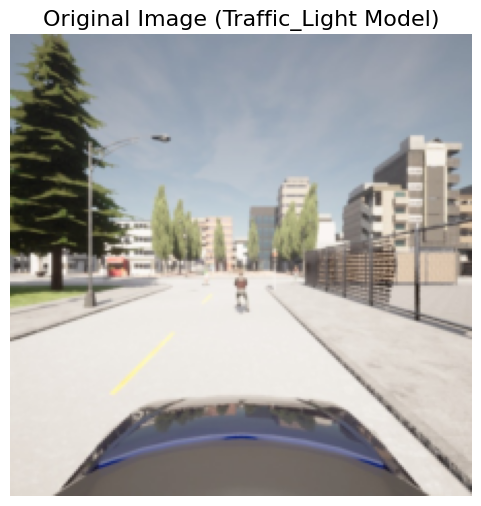

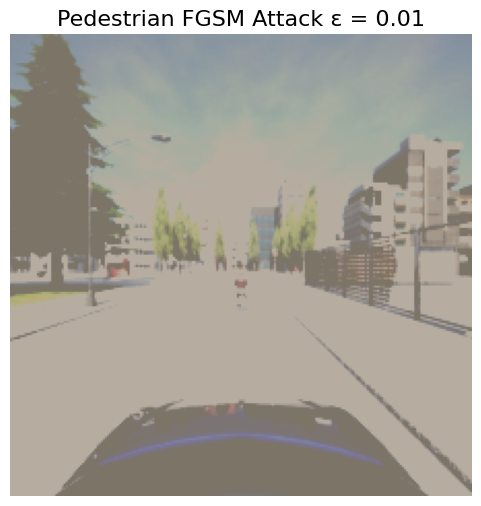

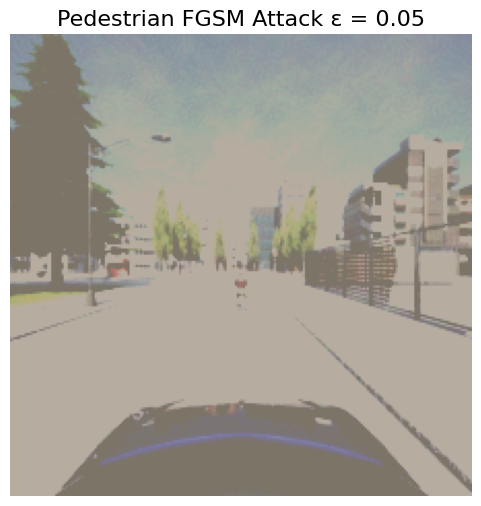

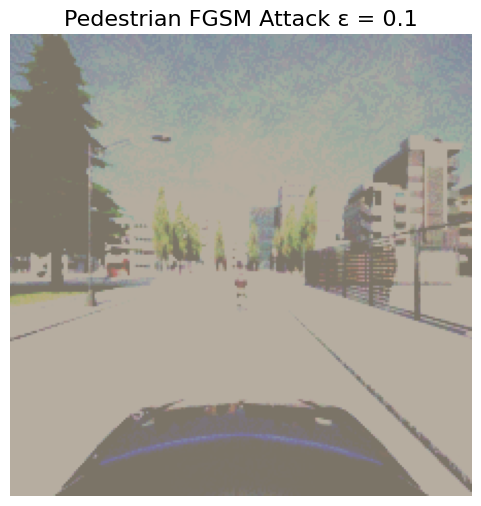

In [81]:
import random
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

images = images.to(device)
ped_labels = labels[:, 1].unsqueeze(1).to(device)


valid_indices = (labels[:, 1] == 1).nonzero(as_tuple=True)[0]

# fallback safety check
if len(valid_indices) == 0:
    raise ValueError("No pedestrian samples in this batch!")

idx = valid_indices[random.randint(0, len(valid_indices)-1)].item()

epsilons = [0.0, 0.01, 0.05, 0.1]

def show_img(img, title=""):
    img = denormalize(img)
    img = img.detach().cpu().permute(1,2,0).numpy()
    plt.imshow(img)
    plt.title(title, fontsize=16)
    plt.axis("off")

# ORIGINAL
plt.figure(figsize=(6,6))
show_img(images[idx], "Original Image (Traffic_Light Model)")
plt.show()

# FGSM SEPARATE IMAGES
for eps in epsilons[1:]:
    adv = fgsm_attack(ped_model, images, ped_labels, eps)

    plt.figure(figsize=(6,6))
    show_img(adv[idx], f"Pedestrian FGSM Attack ε = {eps}")
    plt.show()

In [46]:
import torch

images, labels = next(iter(train_loader))

images = images.to(device)
ped_labels = labels[:, 1].unsqueeze(1).to(device)

epsilons = [0.01, 0.05, 0.1]

print("=== Pedestrian Model Adversarial Accuracy ===")

# Clean accuracy
with torch.no_grad():
    clean_out = torch.sigmoid(ped_model(images))
    clean_pred = (clean_out > 0.5).float()
    clean_acc = (clean_pred == ped_labels).float().mean()

print("Clean accuracy:", clean_acc.item())

# Adversarial accuracy for each epsilon
for eps in epsilons:
    adv_images = fgsm_attack(ped_model, images, ped_labels, eps)

    with torch.no_grad():
        adv_out = torch.sigmoid(ped_model(adv_images))
        adv_pred = (adv_out > 0.5).float()
        adv_acc = (adv_pred == ped_labels).float().mean()

    print(f"Epsilon {eps} → Adversarial accuracy: {adv_acc.item()}")

=== Pedestrian Model Adversarial Accuracy ===
Clean accuracy: 1.0
Epsilon 0.01 → Adversarial accuracy: 0.6875
Epsilon 0.05 → Adversarial accuracy: 0.375
Epsilon 0.1 → Adversarial accuracy: 0.25


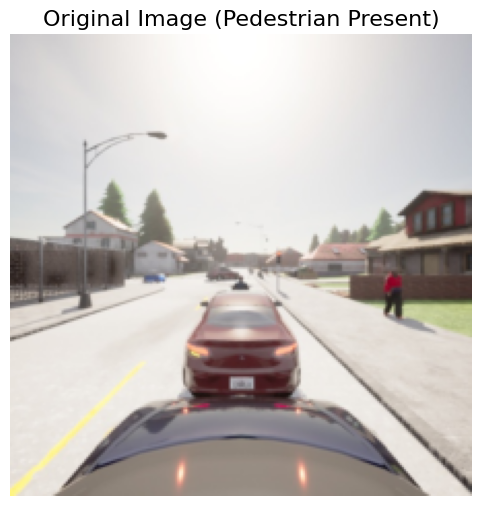

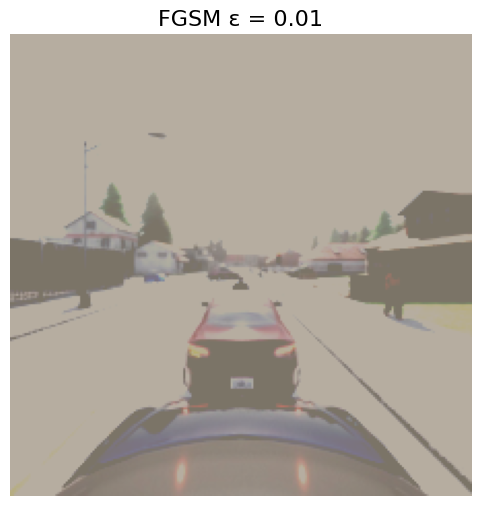

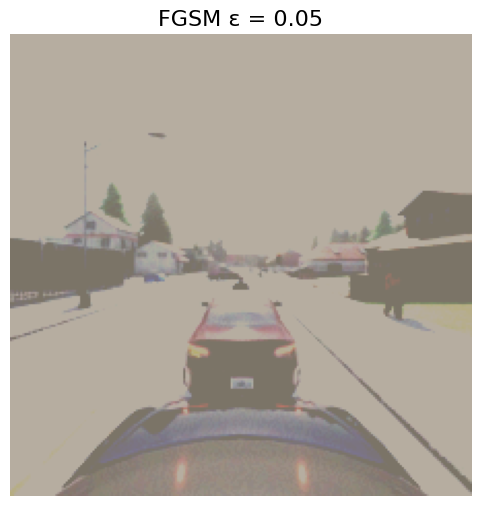

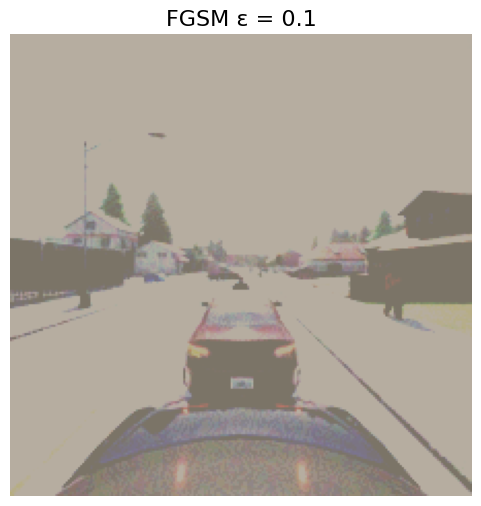

In [55]:
import random
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

images = images.to(device)
ped_labels = labels[:, 1].unsqueeze(1).to(device)

# pick only pedestrian-positive samples
valid_indices = (labels[:, 1] == 1).nonzero(as_tuple=True)[0]

idx = valid_indices[random.randint(0, len(valid_indices)-1)].item()

epsilons = [0.01, 0.05, 0.1]

adv_images = {}
for eps in epsilons:
    adv_images[eps] = fgsm_attack(ped_model, images, ped_labels, eps)

def show_img(img, title=""):
    img = denormalize(img)
    img = img.detach().cpu().permute(1,2,0).numpy()
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.title(title, fontsize=16)
    plt.axis("off")
    plt.show()

# ORIGINAL
show_img(images[idx], "Original Image (Pedestrian Present)")

# FGSM images one-by-one
show_img(adv_images[0.01][idx], "FGSM ε = 0.01")
show_img(adv_images[0.05][idx], "FGSM ε = 0.05")
show_img(adv_images[0.1][idx], "FGSM ε = 0.1")

In [67]:
import torch

images, labels = next(iter(train_loader))

images = images.to(device)
veh_labels = labels[:, 2].unsqueeze(1).to(device)

epsilons = [0.01, 0.05, 0.1]

print("=== Vehicle Model Adversarial Accuracy ===")

# CLEAN ACCURACY
with torch.no_grad():
    clean_out = torch.sigmoid(vehicle_model(images))
    clean_pred = (clean_out > 0.5).float()
    clean_acc = (clean_pred == veh_labels).float().mean()

print("Clean accuracy:", clean_acc.item())

# ADVERSARIAL ACCURACY
for eps in epsilons:
    adv_images = fgsm_attack(vehicle_model, images, veh_labels, eps)

    with torch.no_grad():
        adv_out = torch.sigmoid(vehicle_model(adv_images))
        adv_pred = (adv_out > 0.5).float()
        adv_acc = (adv_pred == veh_labels).float().mean()

    print(f"Epsilon {eps} → Adversarial accuracy: {adv_acc.item()}")

=== Vehicle Model Adversarial Accuracy ===
Clean accuracy: 0.9375
Epsilon 0.01 → Adversarial accuracy: 0.3125
Epsilon 0.05 → Adversarial accuracy: 0.25
Epsilon 0.1 → Adversarial accuracy: 0.125


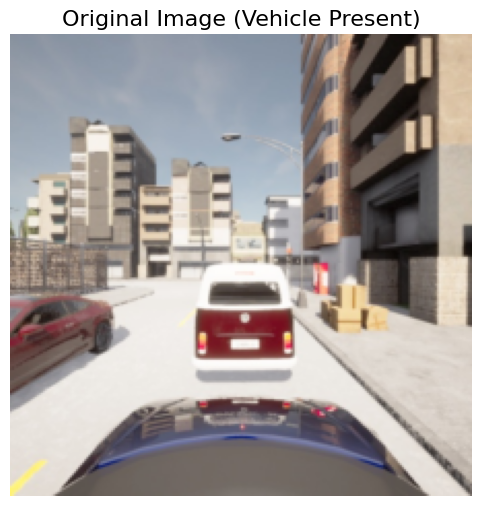

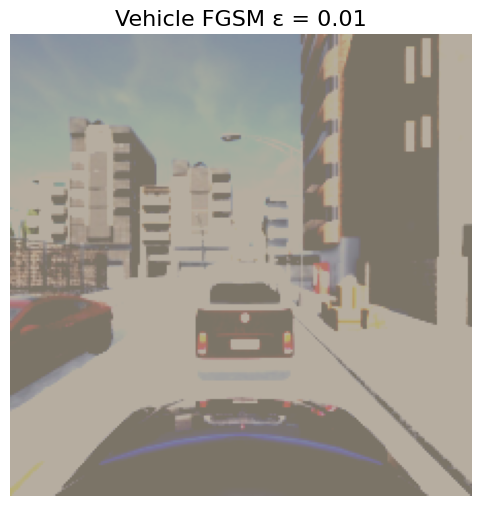

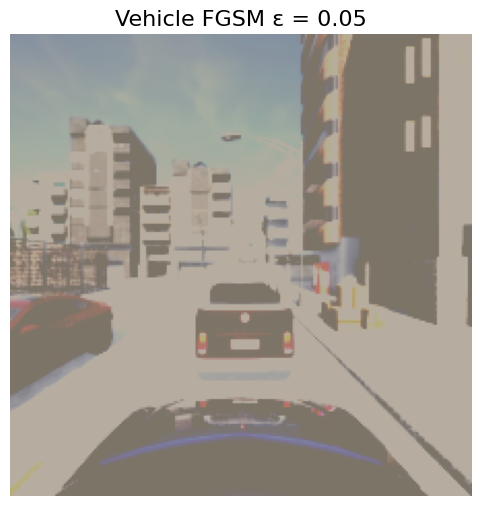

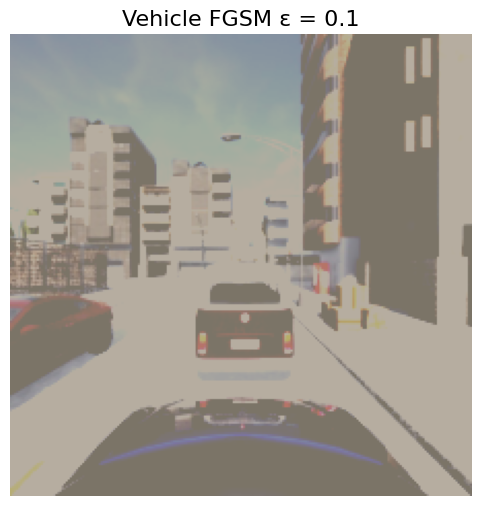

In [66]:
import random
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

images = images.to(device)
veh_labels = labels[:, 2].unsqueeze(1).to(device)

valid_indices = (labels[:, 2] == 1).nonzero(as_tuple=True)[0]

idx = valid_indices[random.randint(0, len(valid_indices)-1)].item()

epsilons = [0.01, 0.05, 0.1]

adv_images = {}
for eps in epsilons:
    adv_images[eps] = fgsm_attack(vehicle_model, images, veh_labels, eps)

def show_img(img, title=""):
    img = denormalize(img)
    img = img.detach().cpu().permute(1,2,0).numpy()
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.title(title, fontsize=16)
    plt.axis("off")
    plt.show()

# ORIGINAL
show_img(images[idx], "Original Image (Vehicle Present)")

# FGSM IMAGES
show_img(adv_images[0.01][idx], "Vehicle FGSM ε = 0.01")
show_img(adv_images[0.05][idx], "Vehicle FGSM ε = 0.05")
show_img(adv_images[0.1][idx], "Vehicle FGSM ε = 0.1")

For ε = 0.01, the perturbations were not visibly distinguishable from the original image. For ε = 0.05, slight visual changes could be observed upon close inspection. For ε = 0.1, the perturbations became clearly noticeable, although the overall scene remained recognizable.

In [80]:
import torch

def recall_score(model, images, labels):
    with torch.no_grad():
        outputs = model(images)
        preds = (torch.sigmoid(outputs) > 0.5).float()

    tp = ((preds == 1) & (labels == 1)).sum().item()
    fn = ((preds == 0) & (labels == 1)).sum().item()

    recall = tp / (tp + fn + 1e-8)
    return recall

In [69]:
def evaluate_model_robustness(model, label_idx, model_name):

    images, labels = next(iter(train_loader))

    images = images[:100].to(device)
    labels = labels[:100, label_idx].unsqueeze(1).to(device)

    print(f"\n=== {model_name} ===")

    # CLEAN RECALL
    clean_recall = recall_score(model, images, labels)
    print("Clean Recall:", clean_recall)

    epsilons = [0.01, 0.05, 0.1]

    for eps in epsilons:
        adv_images = fgsm_attack(model, images, labels, eps)
        adv_recall = recall_score(model, adv_images, labels)

        drop = clean_recall - adv_recall

        print(f"Epsilon {eps} → Recall: {adv_recall:.4f}, Drop: {drop:.4f}")

In [76]:
evaluate_model_robustness(traffic_model, 0, "Traffic Model")



=== Traffic Model ===
Clean Recall: 0.9999999991666666
Epsilon 0.01 → Recall: 0.5833, Drop: 0.4167
Epsilon 0.05 → Recall: 0.3333, Drop: 0.6667
Epsilon 0.1 → Recall: 0.1667, Drop: 0.8333


In [78]:
evaluate_model_robustness(ped_model, 1, "Pedestrian Model")



=== Pedestrian Model ===
Clean Recall: 0.9999999980000001
Epsilon 0.01 → Recall: 0.8000, Drop: 0.2000
Epsilon 0.05 → Recall: 0.6000, Drop: 0.4000
Epsilon 0.1 → Recall: 0.4000, Drop: 0.6000


In [77]:
evaluate_model_robustness(vehicle_model, 2, "Vehicle Model")


=== Vehicle Model ===
Clean Recall: 0.9090909082644627
Epsilon 0.01 → Recall: 0.5455, Drop: 0.3636
Epsilon 0.05 → Recall: 0.3636, Drop: 0.5455
Epsilon 0.1 → Recall: 0.2727, Drop: 0.6364


Recall was used as the evaluation metric because it measures the ability of the model to correctly detect positive objects such as pedestrians, vehicles, and traffic lights. As ε increased, recall decreased for all models, indicating that adversarial perturbations significantly degrade perception performance and reduce model robustness.